Given a m x n matrix mat and an integer threshold, return the maximum side-length of a square with a sum less than or equal to threshold or return 0 if there is no such square.

 

Example 1:

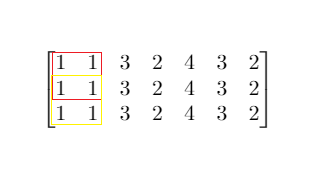

Input: mat = [[1,1,3,2,4,3,2],[1,1,3,2,4,3,2],[1,1,3,2,4,3,2]], threshold = 4
Output: 2
Explanation: The maximum side length of square with sum less than 4 is 2 as shown.

Example 2:

Input: mat = [[2,2,2,2,2],[2,2,2,2,2],[2,2,2,2,2],[2,2,2,2,2],[2,2,2,2,2]], threshold = 1
Output: 0

 

Constraints:

    m == mat.length
    n == mat[i].length
    1 <= m, n <= 300
    0 <= mat[i][j] <= 104
    0 <= threshold <= 105



In [ ]:
class Solution:
    def maxSideLength(self, mat: List[List[int]], threshold: int) -> int:
        size = 0
        m, n = len(mat), len(mat[0])
        p_sum = [[0] for _ in range(m)]
        for i in range(m):
            for j in range(n):
                p_sum[i].append(p_sum[i][-1] + mat[i][j])

        for i in range(m):
            for j in range(n + 1):
                curr_sum = 0
                while curr_sum <= threshold and i + size + 1 <= m and j + size + 1 < n + 1:
                    curr_sum = 0
                    for row in range(i, i + size + 1):
                        curr_sum += p_sum[row][j + size + 1] - p_sum[row][j]
                    if curr_sum <= threshold:
                        size += 1
        return size

In [ ]:
class Solution:
    def maxSideLength(self, mat: List[List[int]], threshold: int) -> int:
        m, n = len(mat), len(mat[0])
        P = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                P[i][j] = (
                    P[i - 1][j]
                    + P[i][j - 1]
                    - P[i - 1][j - 1]
                    + mat[i - 1][j - 1]
                )

        def getRect(x1, y1, x2, y2):
            return P[x2][y2] - P[x1 - 1][y2] - P[x2][y1 - 1] + P[x1 - 1][y1 - 1]

        r, ans = min(m, n), 0
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                for c in range(ans + 1, r + 1):
                    if (
                        i + c - 1 <= m
                        and j + c - 1 <= n
                        and getRect(i, j, i + c - 1, j + c - 1) <= threshold
                    ):
                        ans += 1
                    else:
                        break
        return ans